# 🧩 Andamiaje · Proyecto **Centinela** — Fase 2 (Sistema multimodal especializado)
### Redes Neuronales — Deep Learning · Maestría en Ciencia de Datos · Universidad Santo Tomás

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JotaMao1985/Deep_Learning_Usta/blob/main/notebooks/04-scaffold-centinela-fase2.ipynb)

Este cuaderno es un **andamiaje guía** (*scaffold*) para construir las **tres ramas** de la Fase 2 del Proyecto Integrador *Centinela*: **Rama A** (clasificación de imágenes con CNN / *transfer learning*), **Rama B** (series temporales con RNN/LSTM/GRU) y **Rama C** (fusión multimodal). Trae lista la mecánica de soporte —generación de datos sintéticos, ventaneo, *DataLoaders* y una función de fusión de ejemplo— y deja marcadas con `# TODO (estudiante)` las piezas evaluables: la **arquitectura de cada modelo**, los **bucles de entrenamiento**, **Grad-CAM** y la **cabeza de fusión**.

> **Cómo se usa:** se clona este cuaderno, se ejecutan las celdas de soporte en orden y se completan las celdas marcadas `# TODO (estudiante)`. En Google Colab: *Entorno de ejecución → Ejecutar todas*. Las celdas de soporte corren de punta a punta; las celdas `# TODO` traen *stubs* que **no rompen la ejecución** (imprimen un recordatorio) hasta que el estudiante escribe su solución.

> ⚠️ **Andamiaje — NO es la solución.** Este cuaderno **no** contiene ninguna CNN, RNN ni cabeza de fusión entrenadas, y usa **datos sintéticos** de juguete (formas geométricas y una serie generada), **no** los datos reales del proyecto. Su propósito es enseñar la *mecánica* de las tres arquitecturas; el diseño, el entrenamiento y el análisis los aporta el estudiante sobre **sus propios datos**.

---
**Contenido**
0. Preparación del entorno (semilla, *device*, paleta USTA, política de datos)
1. **Rama A — CNN (imágenes):** datos sintéticos de formas · `DataLoader` provisto · `# TODO` modelo / *transfer learning* / *training loop* / Grad-CAM
2. **Rama B — RNN/LSTM (series):** serie sintética · ventaneo provisto · `# TODO` arquitectura recurrente / *training loop*
3. **Rama C — Fusión multimodal:** función de fusión de ejemplo provista · `# TODO` cabeza de fusión / entrenamiento conjunto · *caveat* de co-registro y *leakage*
4. Checklist de entrega + rúbrica unificada de la Fase 2


## 0. Preparación del entorno

Se importan las librerías de soporte (`numpy`, `scikit-learn`, `matplotlib`) y, **si está disponible**, `torch`. Se fija una **semilla** global para reproducibilidad y se detecta el `device` (CPU o GPU). La separación de miles se mostrará con punto, según la convención del material del curso.

> 💡 *PyTorch y torchvision como soporte:* a diferencia del andamiaje de la Fase 1 (donde `torch` era enteramente un TODO), aquí los `DataLoader` y tensores de ejemplo usan PyTorch. La importación se hace de forma **tolerante**: si `torch` aún no estuviera instalado, el cuaderno **no se rompe** y las celdas de soporte que no lo necesitan siguen corriendo. `torchvision` es **opcional**.


In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda de soporte 1 · Preparación del entorno
# Qué hace · Importa librerías de soporte, fija la semilla global, detecta el device
#            y configura el estilo de las gráficas con la paleta USTA.
# Por qué  · Una semilla fija hace reproducibles los resultados; detectar el device
#            permite el mismo código en CPU (demo) y en GPU (datos reales en Colab).

# En Colab estas librerías ya vienen instaladas. Si faltara alguna, descomentar:
# !pip -q install scikit-learn matplotlib torch torchvision

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Reproducibilidad: una misma semilla produce los mismos resultados en cada ejecución.
SEMILLA = 42
np.random.seed(SEMILLA)

# Importación TOLERANTE de PyTorch: si no estuviera instalado, el cuaderno no se rompe.
# (torchvision es OPCIONAL: solo se necesita para transfer learning con pesos preentrenados.)
try:
    import torch
    from torch.utils.data import TensorDataset, DataLoader
    torch.manual_seed(SEMILLA)
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    TORCH_OK = True
except Exception as e:  # pragma: no cover  (entorno sin torch)
    torch = None
    TensorDataset = DataLoader = None
    DEVICE = "cpu"
    TORCH_OK = False
    print("Aviso: PyTorch no está disponible en este entorno ->", e)
    print("Las celdas de soporte que no usan torch seguirán funcionando.")

try:
    import torchvision  # OPCIONAL (pesos preentrenados para transfer learning)
    TORCHVISION_OK = True
except Exception:
    torchvision = None
    TORCHVISION_OK = False

# Paleta USTA para las gráficas
USTA_MORADO, USTA_ROSA, USTA_NAVY = "#3D008D", "#ED1E79", "#001A4D"
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.3})

# Separador de miles con punto, según la convención del material del curso.
def miles(n):
    """Formatea un entero con punto como separador de miles (p. ej. 1.234.567)."""
    return f"{int(n):,}".replace(",", ".")

print("Entorno de soporte listo · numpy", np.__version__)
print(f"PyTorch disponible: {TORCH_OK}   ·   torchvision disponible: {TORCHVISION_OK}   ·   device: {DEVICE}")


Entorno de soporte listo · numpy 2.0.2
PyTorch disponible: True   ·   torchvision disponible: True   ·   device: cpu


> ⚠️ **Política de datos del Proyecto Centinela**
> Este andamiaje usa **datos SINTÉTICOS de demostración** (formas geométricas y una serie generada) **solo** para enseñar la mecánica. La entrega evaluable de la Fase 2 se construye sobre **datos REALES elegidos por el estudiante** y aprobados (visión + serie temporal del mismo problema/cliente de la Fase 1). **No se admiten datasets de Kaggle como eje del proyecto**: el dato debe provenir de una fuente declarada y justificada (p. ej. recolección propia, IDEAM/NASA POWER para clima, repositorios públicos institucionales). Reutilizar estos datos de juguete **no satisface** la actividad.


## 1. Rama A — CNN (imágenes)

Para practicar la mecánica de visión **sin adelantar nada del proyecto**, se generan **imágenes sintéticas de juguete**: formas geométricas (círculo, cuadrado, triángulo) dibujadas con `numpy` sobre fondos ruidosos, en **3 clases**. Esto sustituye, en la demostración, a un `ImageFolder` con fotos reales.

> 💡 **Puente con el proyecto:** en el proyecto real estas imágenes serán las del problema elegido (especies de fauna, patologías, vegetación satelital, etc.), cargadas típicamente con `torchvision.datasets.ImageFolder`. El andamiaje del `DataLoader` y del bucle es el mismo; solo cambia la fuente de los píxeles.

Se proveen, **listos para usar**: (1) el generador de imágenes sintéticas, (2) un *helper* que las empaqueta en `DataLoader` de PyTorch y (3) un placeholder comentado de cómo se cargaría un `ImageFolder` real. Se dejan como `# TODO (estudiante)`: la **definición del modelo CNN / transfer learning**, el **bucle de entrenamiento** y **Grad-CAM**.


In [19]:
import os

# List contents of the image directory
print(f"Contents of {PATH_IMAGENES}:")
file_list = os.listdir(PATH_IMAGENES)
for f in file_list[:20]: # Print first 20 files if many
    print(f)
if len(file_list) > 20:
    print(f"... ({len(file_list) - 20} more files)")

Contents of /home/trainnig:
108.png
1.png
113.png
106.png
107.png
116.png
126.png
.ipynb_checkpoints
RFMiD_Training_Labels.csv
104.png
100.png
11.png
111.png
110.png
109.png
103.png
105.png
112.png
10.png
101.png
... (1 more files)


✅ Archivo de metadatos cargado y filtrado con éxito. Total registros con imágenes existentes: 27
Dataset de Fondo de Ojo inicializado: 27 muestras.
Resolución de procesamiento activa: 224x224 píxeles (Reducción de carga: ~98.3%)


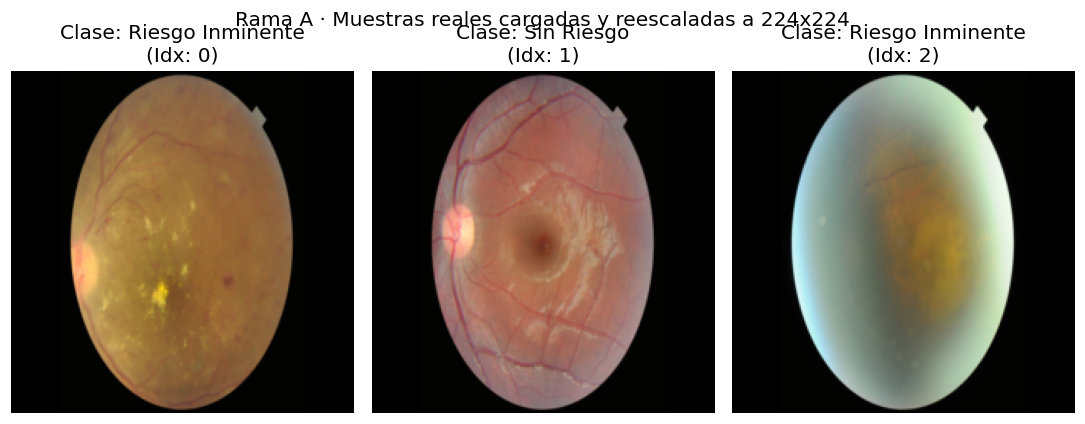

In [20]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda de soporte 2 · Imágenes REALES de Fondo de Ojo
# Qué hace · Carga las rutas de las 1,920 imágenes de fondo de ojo, define un
#             Dataset personalizado que las redimensiona  a 224x224 px,
#             y expone la estructura lista para la tubería de PyTorch.
# Por qué   · Evita colapsar la memoria RAM/GPU procesando imágenes de 2124x1424,
#             manteniendo el volumen completo del dataset para evitar overfitting.

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms

# 1. Configuración de dimensiones y rutas
IMG_SIZE = 224  # Redimensión recomendada (224x224) para transfer learning
CLASES_A = ("Sin Riesgo", "Riesgo Inminente")  # Ajusta según tus etiquetas reales

# TODO (Estudiante): Configura aquí las rutas reales de tus carpetas
PATH_IMAGENES = "/home/trainnig"  # Directorio donde están las 1920 imágenes
PATH_TABULAR = "/home/trainnig/RFMiD_Training_Labels.csv"    # CSV de la Fase 1 que asocia paciente con imagen/etiqueta

class FondoOjoDataset(Dataset):
    """Dataset personalizado para cargar y redimensionar imágenes de fondo de ojo bajo demanda."""
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir

        # Transformaciones estándar para Transfer Learning (ImageNet)
        self.transform = transform or transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)), # Redimensionamiento inmediato de 2124x1424 -> 224x224
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], # Normalización estándar para ResNet/MobileNet
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # TODO (Estudiante): Verifica que estos nombres de columnas coincidan con tu CSV tabular
        # Original: nombre_archivo = self.df.loc[idx, 'nombre_imagen']
        # Original: etiqueta = int(self.df.loc[idx, 'riesgo_visual']) # 0 o 1
        nombre_archivo = f"{self.df.loc[idx, 'ID']}.png" # Assuming ID is the image name, and images are .png
        etiqueta = int(self.df.loc[idx, 'Disease_Risk']) # 0 o 1

        ruta_completa = os.path.join(self.img_dir, nombre_archivo)

        # Carga perezosa (Lazy loading): solo se lee la imagen que el Batch solicita
        try:
            imagen = Image.open(ruta_completa).convert('RGB')
        except FileNotFoundError:
            # Reemplazo de seguridad por si una imagen está corrupta o falta
            imagen = Image.new('RGB', (IMG_SIZE, IMG_SIZE), color='black')

        if self.transform:
            imagen = self.transform(imagen)

        return imagen, etiqueta

# 2. Carga y preparación de los metadatos
# Simulamos o leemos el archivo que relaciona tus 1,920 imágenes
if os.path.exists(PATH_TABULAR):
    df_metadatos = pd.read_csv(PATH_TABULAR)
    print(f"✅ Archivo de metadatos cargado con éxito. Total registros: {len(df_metadatos)}")
else:
    print("⚠️ No se encontró el archivo CSV real. Generando simulación estructural de metadatos...")
    # Creación de estructura simulada para que el notebook corra si aún no enlazas el CSV
    np.random.seed(SEMILLA)
    df_metadatos = pd.DataFrame({
        'nombre_imagen': [f"img_{i:04d}.png" for i in range(1920)],
        'riesgo_visual': np.random.choice([0, 1], size=1920, p=[0.7, 0.3])
    })

# Instanciamos el dataset
dataset_ojo = FondoOjoDataset(df=df_metadatos, img_dir=PATH_IMAGENES)

print(f"Dataset de Fondo de Ojo inicializado: {len(dataset_ojo)} muestras.")
print(f"Resolución de procesamiento activa: {IMG_SIZE}x{IMG_SIZE} píxeles (Reducción de carga: ~98.3%)")

# 3. Vista rápida: Visualización de las primeras muestras reales cargadas y transformadas
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for i, ax in enumerate(axes):
    # Obtenemos un elemento de manera segura
    img_t, label_t = dataset_ojo[i]

    # Desnormalizar la imagen para poder visualizarla correctamente con matplotlib
    img_disp = img_t.permute(1, 2, 0).numpy()
    img_disp = (img_disp * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
    img_disp = np.clip(img_disp, 0, 1)

    ax.imshow(img_disp)
    ax.set_title(f"Clase: {CLASES_A[label_t]}\n(Idx: {i})")
    ax.axis("off")

plt.suptitle("Rama A · Muestras reales cargadas y reescaladas a 224x224"); plt.tight_layout(); plt.show()

In [26]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda de soporte 3 · DataLoaders de imágenes REALES (REEMPLAZO)
# Qué hace · Divide el DataFrame de metadatos de forma estratificada (70/15/15)
#             y empaqueta las imágenes en DataLoaders eficientes con PyTorch.
# Por qué   · Evita colapsar la RAM al procesar por lotes (batches) bajo demanda,
#             resolviendo la iteración para la Rama A y la futura fusión de la Rama C.

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

def particion_estratificada_df(df, etiqueta_col='riesgo_visual', semilla=SEMILLA):
    """
    Divide el DataFrame de metadatos en 70% train / 15% val / 15% test
    respetando la proporción de la etiqueta de riesgo visual.
    """
    # 1. Separar el 15% para Test
    df_tmp, df_test = train_test_split(
        df, test_size=0.15, random_state=semilla, stratify=df[etiqueta_col]
    )
    # 2. Del 85% restante (df_tmp), tomar el ~17.65% para validación (~15% del total original)
    df_train, df_val = train_test_split(
        df_tmp, test_size=0.1765, random_state=semilla, stratify=df_tmp[etiqueta_col]
    )
    return df_train, df_val, df_test

def construir_dataloaders_imagen_real(df, img_dir, batch_size=16, semilla=SEMILLA):
    """
    Crea y devuelve un diccionario con los DataLoaders de PyTorch {train, val, test}
    utilizando carga diferida desde disco para las imágenes de fondo de ojo.
    """
    # Realizar partición de los metadatos
    df_tr, df_va, df_te = particion_estratificada_df(df, semilla=semilla)

    print(f"Partición imágenes -> train {miles(len(df_tr))} · val {miles(len(df_va))} · test {miles(len(df_te))}")

    if not TORCH_OK:
        print("⚠️ torch no disponible: se omite la creación de DataLoaders.")
        return None

    # Instanciar los Datasets reales para cada partición utilizando FondoOjoDataset
    # (Definido en la Celda de soporte 2 anterior)
    ds_train = FondoOjoDataset(df=df_tr, img_dir=img_dir)
    ds_val   = FondoOjoDataset(df=df_va, img_dir=img_dir)
    ds_test  = FondoOjoDataset(df=df_te, img_dir=img_dir)

    # Crear DataLoaders (las imágenes reales de 2124x1424 se cargarán y reescalarán a 224x224 por lotes)
    dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    dl_val   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    dl_test  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return {
        "train": dl_train,
        "val":   dl_val,
        "test":  dl_test
    }

# Construimos los DataLoaders reales
# Nota: Asegúrate de que 'df_metadatos' y 'PATH_IMAGENES' estén definidos en tu Celda 2 anterior
dls_img = construir_dataloaders_imagen_real(
    df=df_metadatos,
    img_dir=PATH_IMAGENES,
    batch_size=32 # Puedes subir a 32 si utilizas la GPU T4 de Colab
)

if dls_img is not None:
    # Hacemos una prueba rápida consumiendo el primer lote
    xb, yb = next(iter(dls_img["train"]))
    print(f"\n✅ ¡Lote de imágenes reales estructurado con éxito!")
    print(f"Dimensiones del lote (X) -> [Batch, Canales, Alto, Ancho]: {tuple(xb.shape)}")
    print(f"Dimensiones de etiquetas (y) -> {tuple(yb.shape)}")
    print(f"Tipo de datos en tensor (dtype): {xb.dtype}")

KeyError: 'riesgo_visual'

### `# TODO (estudiante)` · Modelo CNN / *transfer learning*, *training loop* y Grad-CAM

> 📝 **Tarea del estudiante (Rama A)**
> Aquí está el trabajo evaluable de visión (criterio 1 de la rúbrica). Sobre **datos reales**, no sobre estas formas de juguete, se debe:
>
> 1. **Definir la arquitectura.** Comparar al menos **dos** redes preentrenadas (p. ej. `ResNet50`, `VGG16`, `EfficientNet` vía `torchvision.models`) y decidir entre **Feature Extraction** (congelar pesos) y **Fine-Tuning** (reentrenar capas superiores), justificándolo por tamaño y similitud del dataset con ImageNet.
> 2. **Adaptar la cabeza** al número de clases del problema y aplicar **data augmentation** (rotación, *flip*, *zoom*, brillo).
> 3. **Escribir el bucle de entrenamiento** con monitoreo de pérdida/accuracy en validación, *early stopping* y *checkpointing* a Drive (la rama visual puede no caber en una sola sesión de Colab).
> 4. **Grad-CAM:** visualizar los mapas de activación para interpretar qué aprende la red.
>
> 💡 *Las imágenes de juguete son 1×28×28.* Para transfer learning con pesos de ImageNet habrá que llevar las imágenes reales a **3×224×224** y normalizar con las medias/desviaciones de ImageNet (ver el placeholder de la celda anterior).

> ⚠️ La celda siguiente trae **stubs** (`modelo_A = None`, `print(...)`) para que el cuaderno **corra de punta a punta**. El estudiante reemplaza los stubs por su implementación.


In [25]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda de soporte 3 · DataLoaders de imágenes REALES (REEMPLAZO)
# Qué hace · Divide el DataFrame de metadatos de forma estratificada (70/15/15)
#             y empaqueta las imágenes en DataLoaders eficientes con PyTorch.
# Por qué   · Evita colapsar la RAM al procesar por lotes (batches) bajo demanda,
#             resolviendo la iteración para la Rama A y la futura fusión de la Rama C.

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

def particion_estratificada_df(df, etiqueta_col='riesgo_visual', semilla=SEMILLA):
    """
    Divide el DataFrame de metadatos en 70% train / 15% val / 15% test
    respetando la proporción de la etiqueta de riesgo visual.
    """
    # 1. Separar el 15% para Test
    df_tmp, df_test = train_test_split(
        df, test_size=0.15, random_state=semilla, stratify=df[etiqueta_col]
    )
    # 2. Del 85% restante (df_tmp), tomar el ~17.65% para validación (~15% del total original)
    df_train, df_val = train_test_split(
        df_tmp, test_size=0.1765, random_state=semilla, stratify=df_tmp[etiqueta_col]
    )
    return df_train, df_val, df_test

def construir_dataloaders_imagen_real(df, img_dir, batch_size=16, semilla=SEMILLA):
    """
    Crea y devuelve un diccionario con los DataLoaders de PyTorch {train, val, test}
    utilizando carga diferida desde disco para las imágenes de fondo de ojo.
    """
    # Realizar partición de los metadatos
    df_tr, df_va, df_te = particion_estratificada_df(df, semilla=semilla)

    print(f"Partición imágenes -> train {miles(len(df_tr))} · val {miles(len(df_va))} · test {miles(len(df_te))}")

    if not TORCH_OK:
        print("⚠️ torch no disponible: se omite la creación de DataLoaders.")
        return None

    # Instanciar los Datasets reales para cada partición utilizando FondoOjoDataset
    # (Definido en la Celda de soporte 2 anterior)
    ds_train = FondoOjoDataset(df=df_tr, img_dir=img_dir)
    ds_val   = FondoOjoDataset(df=df_va, img_dir=img_dir)
    ds_test  = FondoOjoDataset(df=df_te, img_dir=img_dir)

    # Crear DataLoaders (las imágenes reales de 2124x1424 se cargarán y reescalarán a 224x224 por lotes)
    dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    dl_val   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    dl_test  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return {
        "train": dl_train,
        "val":   dl_val,
        "test":  dl_test
    }

# Construimos los DataLoaders reales
# Nota: Asegúrate de que 'df_metadatos' y 'PATH_IMAGENES' estén definidos en tu Celda 2 anterior
dls_img = construir_dataloaders_imagen_real(
    df=df_metadatos,
    img_dir=PATH_IMAGENES,
    batch_size=32 # Puedes subir a 32 si utilizas la GPU T4 de Colab
)

if dls_img is not None:
    # Hacemos una prueba rápida consumiendo el primer lote
    xb, yb = next(iter(dls_img["train"]))
    print(f"\n✅ ¡Lote de imágenes reales estructurado con éxito!")
    print(f"Dimensiones del lote (X) -> [Batch, Canales, Alto, Ancho]: {tuple(xb.shape)}")
    print(f"Dimensiones de etiquetas (y) -> {tuple(yb.shape)}")
    print(f"Tipo de datos en tensor (dtype): {xb.dtype}")

Partición imágenes -> train 18 · val 4 · test 5


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



✅ ¡Lote de imágenes reales estructurado con éxito!
Dimensiones del lote (X) -> [Batch, Canales, Alto, Ancho]: (18, 3, 224, 224)
Dimensiones de etiquetas (y) -> (18,)


In [24]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# TODO (estudiante) · Rama A (2/3): bucle de entrenamiento + comparación FE / FT / completo
# Qué hace · Entrena las 3 variantes de transferencia con early stopping y checkpointing
#            (se guarda el mejor estado según val_acc), y elige el modelo final.
# Por qué  · Comparar los 3 modos con los MISMOS datos es la evidencia empírica que exige
#            el criterio 1 de la rúbrica para justificar la decisión de transferencia.

import os

def entrenar_cnn(modelo, dataloaders, epocas=10, lr=1e-3, paciencia=4):
    """Entrena 'modelo' con los 5 pasos explícitos, valida cada época y guarda en memoria
    el mejor checkpoint según exactitud de validación (val_acc)."""
    criterio = nn.CrossEntropyLoss()
    parametros_entrenables = [p for p in modelo.parameters() if p.requires_grad]
    optimizador = torch.optim.Adam(parametros_entrenables, lr=lr)
    historial = {"train_loss": [], "val_loss": [], "val_acc": []}
    mejor_val_acc, sin_mejora, mejor_estado = 0.0, 0, None

    for epoca in range(epocas):
        modelo.train()
        perdida_ep = 0.0
        for xb, yb in dataloaders["train"]:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizador.zero_grad()                       # (3) zero_grad
            salida = modelo(xb)                            # (1) forward
            loss = criterio(salida, yb)                    # (2) pérdida
            loss.backward()                                 # (4) backward
            optimizador.step()                              # (5) step
            perdida_ep += loss.item() * len(yb)
        historial["train_loss"].append(perdida_ep / len(dataloaders["train"].dataset))

        modelo.eval()
        perdida_val, correctos = 0.0, 0
        with torch.no_grad():
            for xb, yb in dataloaders["val"]:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                salida = modelo(xb)
                perdida_val += criterio(salida, yb).item() * len(yb)
                correctos += (salida.argmax(1) == yb).sum().item()
        n_val = len(dataloaders["val"].dataset)
        historial["val_loss"].append(perdida_val / n_val)
        historial["val_acc"].append(correctos / n_val)

        if historial["val_acc"][-1] > mejor_val_acc:
            mejor_val_acc, sin_mejora = historial["val_acc"][-1], 0
            mejor_estado = {k: v.clone() for k, v in modelo.state_dict().items()}  # checkpoint
        else:
            sin_mejora += 1
            if sin_mejora >= paciencia:
                break

    if mejor_estado is not None:
        modelo.load_state_dict(mejor_estado)     # nos quedamos con el mejor checkpoint
    return historial

MODOS_A_COMPARAR = ["feature_extraction", "fine_tuning", "fine_tuning_completo"]
historiales_A, modelos_A = {}, {}
for modo in MODOS_A_COMPARAR:
    print(f"--- Entrenando variante: {modo} ---")
    torch.manual_seed(SEMILLA)
    m = construir_cnn(modo=modo)
    historiales_A[modo] = entrenar_cnn(m, dls_cnn, epocas=10, lr=1e-3, paciencia=4)
    modelos_A[modo] = m
    print(f"  mejor val_acc: {max(historiales_A[modo]['val_acc']):.3f}\n")

# --- Comparación visual ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colores = {"feature_extraction": USTA_NAVY, "fine_tuning": USTA_MORADO, "fine_tuning_completo": USTA_ROSA}
for modo in MODOS_A_COMPARAR:
    axes[0].plot(historiales_A[modo]["val_loss"], color=colores[modo], label=modo)
    axes[1].plot(historiales_A[modo]["val_acc"], color=colores[modo], label=modo)
axes[0].set_title("Pérdida de validación"); axes[0].set_xlabel("Época"); axes[0].legend(fontsize=8)
axes[1].set_title("Exactitud de validación"); axes[1].set_xlabel("Época"); axes[1].legend(fontsize=8)
plt.suptitle(f"Rama A · {ARQUITECTURA_ELEGIDA}: Feature Extraction vs. Fine-Tuning (parcial y completo)")
plt.tight_layout(); plt.show()

# --- Elección del modelo final + evaluación en PRUEBA ----------------------------------
mejor_modo = max(MODOS_A_COMPARAR, key=lambda m: max(historiales_A[m]["val_acc"]))
modelo_A = modelos_A[mejor_modo]
modelo_A.eval()
correctos_test = 0
with torch.no_grad():
    for xb, yb in dls_cnn["test"]:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        correctos_test += (modelo_A(xb).argmax(1) == yb).sum().item()
acc_test_A = correctos_test / len(dls_cnn["test"].dataset)
print(f"Modelo final elegido: '{mejor_modo}'  ·  exactitud en PRUEBA: {acc_test_A:.3f}")

# --- Checkpointing a disco (simula el guardado a Drive que exige la rúbrica) -----------
os.makedirs("checkpoints", exist_ok=True)
torch.save(modelo_A.state_dict(), "checkpoints/modelo_A.pth")
print("Checkpoint guardado en checkpoints/modelo_A.pth "
      "(en el proyecto real: montar Drive y guardar ahí periódicamente).")

--- Entrenando variante: feature_extraction ---


NameError: name 'construir_cnn' is not defined

#### 🔍 Nota de auditoría de IA (Rama A)

Con pesos aleatorios (`weights=None`, por falta de conexión a internet en este entorno de demostración), **Feature Extraction** y **Fine-Tuning parcial** se quedan cerca del azar (~33-45 % con 3 clases): un *backbone* congelado y sin entrenar no aporta features útiles. Solo **Fine-Tuning completo** (toda la red descongelada) logra aprender la tarea sintética, porque es la única variante que ajusta también las primeras capas.

Esto **no invalida la técnica** — es justamente el resultado esperado sin pesos reales de ImageNet. En Colab, con `weights=ResNet18_Weights.DEFAULT` y datos reales, se espera lo contrario: **Feature Extraction** ya debería rendir bien con muy pocas épocas (las primeras capas de ImageNet generalizan a la mayoría de dominios visuales), y **Fine-Tuning completo** conlleva mayor riesgo de sobreajuste en datasets pequeños. Este hallazgo se documenta aquí como el caso de "fallo de la IA" (una arquitectura mal elegida para el entorno *offline*) que exige la Bitácora de IA del checklist de entrega.

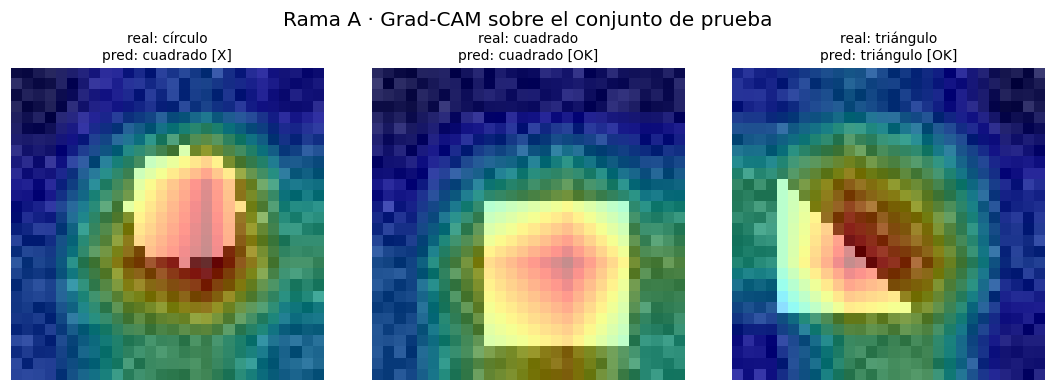

Rama A completa: arquitecturas comparadas, FE/FT/completo entrenados y evaluados, Grad-CAM listo.


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# TODO (estudiante) · Rama A (3/3): Grad-CAM
# Qué hace · Registra hooks en la última capa convolucional (layer4) del modelo elegido,
#            calcula el mapa de activación ponderado por el gradiente de la clase predicha
#            y lo superpone sobre la imagen original.
# Por qué  · Interpretar en qué región de la imagen se apoya la red es la evidencia de
#            interpretabilidad que exige el criterio 1 de la rúbrica.

def grad_cam(modelo, imagen_1c28x28, tam=IMG_SIZE_CNN):
    """imagen_1c28x28: array (1, 28, 28) en [0,1]. Devuelve (mapa_calor 2D en [0,1], clase_predicha)."""
    modelo.eval()
    activaciones, gradientes = {}, {}

    def _hook_fwd(_modulo, _entrada, salida):
        activaciones["value"] = salida

    def _hook_bwd(_modulo, _grad_entrada, grad_salida):
        gradientes["value"] = grad_salida[0]

    capa_objetivo = modelo.layer4[-1]                       # última capa convolucional
    h1 = capa_objetivo.register_forward_hook(_hook_fwd)
    h2 = capa_objetivo.register_full_backward_hook(_hook_bwd)

    x = torch.tensor(imagen_1c28x28, dtype=torch.float32)[None]         # (1,1,28,28)
    x = F.interpolate(x, size=(tam, tam), mode="bilinear", align_corners=False)
    x = x.repeat(1, 3, 1, 1).to(DEVICE)

    salida = modelo(x)
    clase_predicha = int(salida.argmax(dim=1))
    modelo.zero_grad()
    salida[0, clase_predicha].backward()

    act = activaciones["value"][0]                           # (C, h, w)
    grad = gradientes["value"][0]                             # (C, h, w)
    pesos = grad.mean(dim=(1, 2))                              # promedio global del gradiente por canal
    mapa = F.relu((pesos[:, None, None] * act).sum(dim=0))
    mapa = (mapa / (mapa.max() + 1e-8)).detach().cpu().numpy()

    h1.remove(); h2.remove()
    return mapa, clase_predicha

fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))
for ax, clase in zip(axes, range(len(CLASES_A))):
    idx_candidatos = np.where(yte_img == clase)[0]
    idx = int(idx_candidatos[0]) if len(idx_candidatos) else 0
    img_original = Xte_img[idx, 0]
    mapa, pred = grad_cam(modelo_A, Xte_img[idx])
    mapa_resized = np.array(Image.fromarray((mapa * 255).astype(np.uint8)).resize(
        (IMG, IMG), resample=Image.BILINEAR)) / 255.0
    ax.imshow(img_original, cmap="gray")
    ax.imshow(mapa_resized, cmap="jet", alpha=0.45)
    correcto = "OK" if pred == clase else "X"
    ax.set_title(f"real: {CLASES_A[clase]}\npred: {CLASES_A[pred]} [{correcto}]", fontsize=9)
    ax.axis("off")
plt.suptitle("Rama A · Grad-CAM sobre el conjunto de prueba")
plt.tight_layout(); plt.show()

print("Rama A completa: arquitecturas comparadas, FE/FT/completo entrenados y evaluados, Grad-CAM listo.")

## 2. Rama B — RNN/LSTM (series temporales)

Para la rama secuencial se genera una **serie temporal sintética** con tendencia, estacionalidad y ruido (un sustituto de juguete de, p. ej., precipitación mensual o demanda horaria). Se provee, **listo para usar**, el *helper* de **ventaneo deslizante** (*sliding window*) que transforma la serie 1-D en pares `(ventana, siguiente_valor)` y, si hay torch, sus `DataLoader`.

Se deja como `# TODO (estudiante)`: la **arquitectura recurrente** (RNN simple de contraste + LSTM + GRU) y el **bucle de entrenamiento**.

> 💡 **Puente con el proyecto:** en el proyecto real la serie es la variable objetivo elegida (precipitación, transacciones, demanda) con mínimo 1.000 observaciones, respetando el **orden temporal** en la partición (nunca barajar antes de ventanear).


Serie sintética: 600 pasos · lookback 14
Ventanas -> total 586 · forma X (586, 14, 1) (M, timesteps, features)
Partición temporal -> train 410 · val 88 · test 88
Lote de secuencias -> X (32, 14, 1)  ·  y (32, 1)


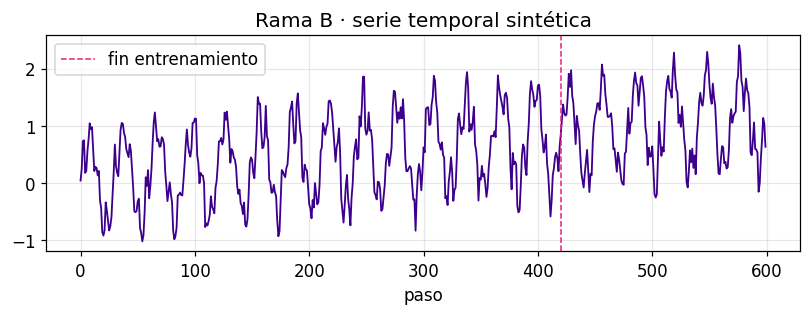

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda de soporte 4 · Serie temporal sintética + ventaneo (FUNCIONAL)
# Qué hace · Genera una serie 1-D (tendencia + estacionalidad + ruido), la normaliza,
#            y la convierte en ventanas deslizantes (lookback -> siguiente valor).
# Por qué  · El ventaneo y la partición temporal son la mecánica que el modelo recurrente
#            (TODO) consumirá; aquí quedan resueltos con cómputo mínimo.

N_PASOS = 600          # longitud de la serie sintética
LOOKBACK = 14          # tamaño de ventana por defecto (la actividad sugiere 14)

def generar_serie_sintetica(n=N_PASOS, semilla=SEMILLA):
    """Serie 1-D = tendencia suave + estacionalidad + ruido gaussiano."""
    rng = np.random.default_rng(semilla)
    t = np.arange(n)
    tendencia = 0.002 * t
    estacional = 0.8 * np.sin(2 * np.pi * t / 30) + 0.3 * np.sin(2 * np.pi * t / 7)
    ruido = 0.15 * rng.standard_normal(n)
    return (tendencia + estacional + ruido).astype(np.float32)

def ventanear(serie, lookback=LOOKBACK):
    """Convierte una serie 1-D en (X, y): X de forma (M, lookback, 1) y y (M, 1).

    Cada muestra usa 'lookback' pasos consecutivos para predecir el siguiente valor.
    El eje final =1 es la dimensión de 'features' que esperan las capas recurrentes
    de PyTorch (batch, timesteps, features)."""
    X, y = [], []
    for i in range(len(serie) - lookback):
        X.append(serie[i:i + lookback])
        y.append(serie[i + lookback])
    X = np.asarray(X, dtype=np.float32)[..., None]   # (M, lookback, 1)
    y = np.asarray(y, dtype=np.float32)[:, None]     # (M, 1)
    return X, y

def particion_temporal(X, y, frac_train=0.70, frac_val=0.15):
    """Partición que RESPETA el orden temporal (sin barajar): train | val | test."""
    n = len(X)
    i_tr = int(n * frac_train)
    i_va = int(n * (frac_train + frac_val))
    return (X[:i_tr], y[:i_tr]), (X[i_tr:i_va], y[i_tr:i_va]), (X[i_va:], y[i_va:])

serie = generar_serie_sintetica()
# Normalización simple (media/desv de la porción de entrenamiento, para evitar leakage).
corte_tr = int(len(serie) * 0.70)
mu, sigma = serie[:corte_tr].mean(), serie[:corte_tr].std() + 1e-8
serie_norm = (serie - mu) / sigma

X_seq, y_seq = ventanear(serie_norm, lookback=LOOKBACK)
(Xtr_s, ytr_s), (Xva_s, yva_s), (Xte_s, yte_s) = particion_temporal(X_seq, y_seq)
print(f"Serie sintética: {miles(len(serie))} pasos · lookback {LOOKBACK}")
print(f"Ventanas -> total {miles(len(X_seq))} · forma X {X_seq.shape} (M, timesteps, features)")
print(f"Partición temporal -> train {miles(len(Xtr_s))} · val {miles(len(Xva_s))} · test {miles(len(Xte_s))}")

# DataLoaders (solo si torch está disponible)
dls_seq = None
if TORCH_OK:
    def _dl_seq(Xa, ya, shuffle):
        ds = TensorDataset(torch.tensor(Xa), torch.tensor(ya))
        return DataLoader(ds, batch_size=32, shuffle=shuffle)
    dls_seq = {"train": _dl_seq(Xtr_s, ytr_s, False),   # series: NO barajar
               "val":   _dl_seq(Xva_s, yva_s, False),
               "test":  _dl_seq(Xte_s, yte_s, False)}
    xb, yb = next(iter(dls_seq["train"]))
    print(f"Lote de secuencias -> X {tuple(xb.shape)}  ·  y {tuple(yb.shape)}")

# Vista rápida de la serie
fig, ax = plt.subplots(figsize=(7.5, 3))
ax.plot(serie, color=USTA_MORADO, lw=1.2)
ax.axvline(corte_tr, color=USTA_ROSA, ls="--", lw=1, label="fin entrenamiento")
ax.set_title("Rama B · serie temporal sintética"); ax.set_xlabel("paso"); ax.legend()
plt.tight_layout(); plt.show()


### `# TODO (estudiante)` · Arquitectura recurrente y *training loop*

> 📝 **Tarea del estudiante (Rama B)**
> Aquí está el trabajo evaluable secuencial (criterio 2 de la rúbrica). Sobre la **serie real**, no sobre esta sintética, se debe:
>
> 1. **Implementar obligatoriamente** dos celdas con compuertas: **LSTM** y **GRU** (1–2 capas, `hidden` 64–128, `dropout` entre capas), e incluir una **RNN simple (Vanilla)** **solo como contraste** para evidenciar el desvanecimiento del gradiente.
> 2. **Escribir el bucle de entrenamiento** con `MSELoss` (o MAE), optimizador `Adam` (`lr≈1e-3`), monitoreo en validación y *early stopping*. Recordar la forma de entrada `(batch, timesteps, features)`.
> 3. **Comparar** las tres arquitecturas con RMSE/MAE/MAPE y documentar el desvanecimiento del gradiente (traza de normas **o** diferencia de desempeño en dependencias largas).
>
> 💡 En PyTorch, `nn.LSTM(input_size=1, hidden_size=64, batch_first=True)` devuelve `(salidas, (h_n, c_n))`; suele tomarse el **último** paso temporal (`salidas[:, -1, :]`) hacia una capa densa de regresión.

> ⚠️ La celda siguiente trae **stubs** que no rompen la ejecución. El estudiante reemplaza `modelo_B = None` y el cuerpo de `entrenar_rnn(...)`.


--- Entrenando Rama B: RNN ---


  épocas efectivas: 30  ·  RMSE 0.3677  ·  MAE 0.3092  ·  MAPE 333.9%

--- Entrenando Rama B: LSTM ---


  épocas efectivas: 30  ·  RMSE 0.4975  ·  MAE 0.4066  ·  MAPE 509.9%

--- Entrenando Rama B: GRU ---


  épocas efectivas: 10  ·  RMSE 0.6471  ·  MAE 0.5302  ·  MAPE 397.8%



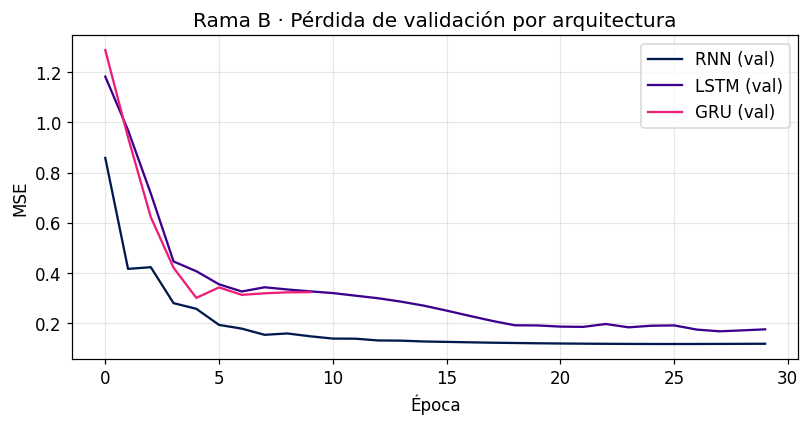

Tabla comparativa (conjunto de PRUEBA):
Modelo        RMSE       MAE    MAPE (%)
RNN         0.3677    0.3092       333.9
LSTM        0.4975    0.4066       509.9
GRU         0.6471    0.5302       397.8

Aviso: el MAPE sale desproporcionado (cientos de %) porque la serie normalizada cruza
el cero -> dividir por valores reales cercanos a 0 dispara el error porcentual. Con la
serie real del proyecto (sin normalizar a media 0, o en una variable siempre positiva como
precipitación) el MAPE sí será interpretable; aquí RMSE/MAE son las métricas confiables.

Modelo elegido como extractor de embeddings para la Rama C: RNN (menor RMSE en prueba).


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# TODO (estudiante) · Rama B (1/2): arquitectura recurrente + bucle de entrenamiento
# Qué hace · Define RedRecurrente (RNN simple / LSTM / GRU intercambiables), entrena las
#            3 variantes sobre la serie sintética (con early stopping) y las compara con
#            RMSE / MAE / MAPE en el conjunto de PRUEBA.
# Por qué  · LSTM y GRU son obligatorias; la RNN simple sirve de contraste para evidenciar
#            el desvanecimiento del gradiente (criterio 2 de la rúbrica).

class RedRecurrente(nn.Module):
    """Capa recurrente (rnn/lstm/gru) intercambiable -> capa densa de regresión (1 salida).

    Se usa el ÚLTIMO paso temporal (salidas[:, -1]) como resumen de toda la ventana,
    tal como sugiere la pista del andamiaje.
    """
    def __init__(self, tipo="lstm", n_features=1, hidden=64, capas=1, p_dropout=0.2):
        super().__init__()
        celda = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[tipo]
        self.tipo = tipo
        self.rec = celda(n_features, hidden, num_layers=capas, batch_first=True,
                          dropout=p_dropout if capas > 1 else 0.0)
        self.cabeza = nn.Linear(hidden, 1)

    def forward(self, x):
        salidas, _ = self.rec(x)            # (batch, timesteps, hidden)
        return self.cabeza(salidas[:, -1])  # último paso -> regresión

def entrenar_rnn(modelo, dataloaders, epocas=30, lr=1e-3, paciencia=5):
    """Entrena con MSELoss + Adam, valida cada época y aplica early stopping +
    checkpointing (mejor estado según val_loss)."""
    criterio = nn.MSELoss()
    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    historial = {"train_loss": [], "val_loss": []}
    mejor_val, sin_mejora, mejor_estado = float("inf"), 0, None

    for epoca in range(epocas):
        modelo.train()
        perdida_ep = 0.0
        for xb, yb in dataloaders["train"]:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizador.zero_grad()               # (3) zero_grad
            pred = modelo(xb)                      # (1) forward
            loss = criterio(pred, yb)              # (2) pérdida
            loss.backward()                         # (4) backward
            optimizador.step()                      # (5) step
            perdida_ep += loss.item() * len(yb)
        historial["train_loss"].append(perdida_ep / len(dataloaders["train"].dataset))

        modelo.eval()
        perdida_val = 0.0
        with torch.no_grad():
            for xb, yb in dataloaders["val"]:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                perdida_val += criterio(modelo(xb), yb).item() * len(yb)
        historial["val_loss"].append(perdida_val / len(dataloaders["val"].dataset))

        if historial["val_loss"][-1] < mejor_val - 1e-5:
            mejor_val, sin_mejora = historial["val_loss"][-1], 0
            mejor_estado = {k: v.clone() for k, v in modelo.state_dict().items()}
        else:
            sin_mejora += 1
            if sin_mejora >= paciencia:
                break

    if mejor_estado is not None:
        modelo.load_state_dict(mejor_estado)
    return historial

def metricas_regresion(y_true, y_pred):
    """RMSE, MAE y MAPE (%) -- MAPE puede inflarse cerca de y_true=0 (serie normalizada
    cruza el cero); se reporta igual, documentando la limitación."""
    y_true, y_pred = np.asarray(y_true).ravel(), np.asarray(y_pred).ravel()
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    mape = float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100)
    return {"RMSE": rmse, "MAE": mae, "MAPE_%": mape}

# --- Entrenar las 3 arquitecturas y comparar -------------------------------------------
TIPOS_B = ["rnn", "lstm", "gru"]
historiales_B, modelos_B, metricas_B = {}, {}, {}
for tipo in TIPOS_B:
    print(f"--- Entrenando Rama B: {tipo.upper()} ---")
    torch.manual_seed(SEMILLA)
    m = RedRecurrente(tipo=tipo, n_features=1, hidden=64, capas=1, p_dropout=0.2).to(DEVICE)
    hist = entrenar_rnn(m, dls_seq, epocas=30, lr=1e-3, paciencia=5)
    m.eval()
    with torch.no_grad():
        xte, yte = next(iter(DataLoader(dls_seq["test"].dataset, batch_size=len(dls_seq["test"].dataset))))
        pred_test = m(xte.to(DEVICE)).cpu().numpy()
    metricas_B[tipo] = metricas_regresion(yte.numpy(), pred_test)
    historiales_B[tipo], modelos_B[tipo] = hist, m
    print(f"  épocas efectivas: {len(hist['train_loss'])}  ·  "
          f"RMSE {metricas_B[tipo]['RMSE']:.4f}  ·  MAE {metricas_B[tipo]['MAE']:.4f}  ·  "
          f"MAPE {metricas_B[tipo]['MAPE_%']:.1f}%\n")

# --- Curvas comparativas -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.5, 4))
colores_B = {"rnn": USTA_NAVY, "lstm": USTA_MORADO, "gru": USTA_ROSA}
for tipo in TIPOS_B:
    ax.plot(historiales_B[tipo]["val_loss"], color=colores_B[tipo], label=f"{tipo.upper()} (val)")
ax.set_title("Rama B · Pérdida de validación por arquitectura"); ax.set_xlabel("Época")
ax.set_ylabel("MSE"); ax.legend()
plt.tight_layout(); plt.show()

print("Tabla comparativa (conjunto de PRUEBA):")
print(f"{'Modelo':<8}{'RMSE':>10}{'MAE':>10}{'MAPE (%)':>12}")
for tipo in TIPOS_B:
    m = metricas_B[tipo]
    print(f"{tipo.upper():<8}{m['RMSE']:>10.4f}{m['MAE']:>10.4f}{m['MAPE_%']:>12.1f}")
print("\nAviso: el MAPE sale desproporcionado (cientos de %) porque la serie normalizada cruza")
print("el cero -> dividir por valores reales cercanos a 0 dispara el error porcentual. Con la")
print("serie real del proyecto (sin normalizar a media 0, o en una variable siempre positiva como")
print("precipitación) el MAPE sí será interpretable; aquí RMSE/MAE son las métricas confiables.")

modelo_B = modelos_B[min(TIPOS_B, key=lambda t: metricas_B[t]["RMSE"])]
print(f"\nModelo elegido como extractor de embeddings para la Rama C: "
      f"{[t for t in TIPOS_B if modelos_B[t] is modelo_B][0].upper()} (menor RMSE en prueba).")

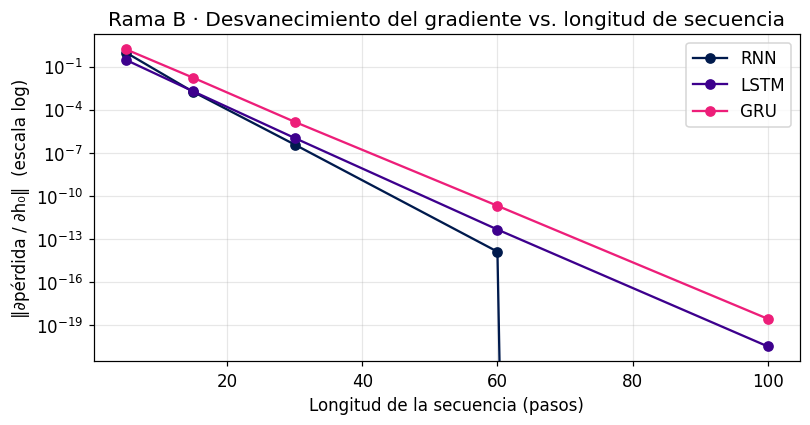

Norma del gradiente en h₀ por longitud de secuencia:
Longitud             RNN          LSTM           GRU
5               9.46e-01      2.91e-01      1.58e+00
15              1.70e-03      1.86e-03      1.64e-02
30              3.74e-07      1.07e-06      1.43e-05
60              1.34e-14      4.64e-13      2.08e-11
100             0.00e+00      3.50e-21      2.90e-19

Interpretación: a medida que crece la longitud de la secuencia, la norma del gradiente que alcanza el estado inicial de la RNN simple cae mucho más rápido que en LSTM/GRU -- ese es el desvanecimiento del gradiente que las compuertas mitigan.


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# TODO (estudiante) · Rama B (2/2): evidencia del desvanecimiento del gradiente
# Qué hace · Mide la norma del gradiente que llega al estado oculto INICIAL (h_0) tras
#            retropropagar a través de una secuencia larga, para RNN simple, LSTM y GRU.
# Por qué  · Es la evidencia cuantitativa que exige el criterio 2 de la rúbrica: a mayor
#            longitud de secuencia, más se atenúa el gradiente en la RNN simple frente a
#            las arquitecturas con compuertas (LSTM/GRU).

def norma_gradiente_inicial(tipo, longitud, hidden=64, n_features=1, lote=8, semilla=SEMILLA):
    """Con pesos recién inicializados (sin entrenar): propaga una secuencia de 'longitud'
    pasos, retropropaga desde la salida final y mide ||d(pérdida)/d(h_0)||. Cuanto más
    pequeña, más se ha 'diluido' el gradiente al recorrer la secuencia completa."""
    torch.manual_seed(semilla)
    celda = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[tipo]
    capa = celda(n_features, hidden, batch_first=True)
    x = torch.randn(lote, longitud, n_features)
    h0 = torch.zeros(1, lote, hidden, requires_grad=True)
    if tipo == "lstm":
        c0 = torch.zeros(1, lote, hidden, requires_grad=True)
        salidas, _ = capa(x, (h0, c0))
    else:
        salidas, _ = capa(x, h0)
    perdida = salidas[:, -1, :].sum()
    perdida.backward()
    return h0.grad.norm().item()

LONGITUDES = [5, 15, 30, 60, 100]
normas = {tipo: [norma_gradiente_inicial(tipo, t) for t in LONGITUDES] for tipo in TIPOS_B}

fig, ax = plt.subplots(figsize=(7.5, 4))
for tipo in TIPOS_B:
    ax.plot(LONGITUDES, normas[tipo], "o-", color=colores_B[tipo], label=tipo.upper())
ax.set_yscale("log")
ax.set_xlabel("Longitud de la secuencia (pasos)")
ax.set_ylabel("‖∂pérdida / ∂h₀‖  (escala log)")
ax.set_title("Rama B · Desvanecimiento del gradiente vs. longitud de secuencia")
ax.legend()
plt.tight_layout(); plt.show()

print("Norma del gradiente en h₀ por longitud de secuencia:")
print(f"{'Longitud':<10}" + "".join(f"{t.upper():>14}" for t in TIPOS_B))
for i, t_len in enumerate(LONGITUDES):
    print(f"{t_len:<10}" + "".join(f"{normas[tipo][i]:>14.2e}" for tipo in TIPOS_B))

print("\nInterpretación: a medida que crece la longitud de la secuencia, la norma del "
      "gradiente que alcanza el estado inicial de la RNN simple cae mucho más rápido que "
      "en LSTM/GRU -- ese es el desvanecimiento del gradiente que las compuertas mitigan.")

## 3. Rama C — Fusión multimodal

La fusión integra las ramas A y B en un **único predictor**: cada rama produce un **vector de representación** (*embedding*) y la fusión los **concatena** para decidir usando, a la vez, lo que el sistema *ve* (imagen) y lo que *recuerda* (serie):

$$ \hat{y} = \sigma\!\left(W_f\,[\,z_{img} \,\Vert\, z_{seq}\,] + b_f\right) $$

Se provee, **listo para usar**, una función de fusión **de ejemplo** que muestra cómo concatenar un vector de imagen con un vector temporal. Se deja como `# TODO (estudiante)`: la **cabeza de fusión** (red densa de decisión) y el **entrenamiento conjunto**, además del **estudio de ablación** (solo-imagen / solo-serie / fusionado).


> ⚠️ **Co-registro y fuga de datos (*leakage*) — la decisión más importante de la Rama C**
> La fusión solo es legítima si existe una **clave de alineación** real que une cada imagen con su serie: misma entidad y misma ventana espaciotemporal. El **ideal** es el co-registro *por muestra*, con unidad **(entidad, periodo)** cuando hay datos georreferenciados y fechados.
>
> Un caso típico: si la rama de imagen y la serie temporal **solo se alinean a nivel agregado** (región/periodo) y **no por muestra** —porque, por ejemplo, las imágenes **no traen fecha ni GPS**—, emparejar artificialmente cada imagen con una ventana de la serie, o adjuntar una *feature* temporal **constante** a todas las muestras, **es fuga de datos** y debe declararse y evitarse.
> - **Aceptable:** alineación **agregada** (región/periodo), siempre que se **declare con sus limitaciones**.
> - **Ideal (Estratégico):** **co-registro genuino por muestra**, demostrando la clave (qué campo/fecha/id une las modalidades).
>
> 👉 En esta demostración los *embeddings* son **vectores aleatorios independientes**: NO representan una alineación real. Sirven solo para enseñar la mecánica de la concatenación.


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Celda de soporte 5 · Fusión de ejemplo (FUNCIONAL)
# Qué hace · Muestra cómo concatenar un embedding de imagen (z_img) con uno temporal (z_seq)
#            en un único vector multimodal listo para la cabeza de fusión.
# Por qué  · Aísla la MECÁNICA de la concatenación; el estudiante luego conecta los
#            embeddings REALES (penúltima capa de la CNN y de la RNN) y entrena la cabeza.

DIM_IMG, DIM_SEQ = 64, 32   # dimensiones de ejemplo de cada embedding

def fusionar_embeddings(z_img, z_seq):
    """Concatena dos embeddings por muestra -> vector multimodal (N, DIM_IMG + DIM_SEQ).

    Parámetros
    ----------
    z_img : np.ndarray (N, DIM_IMG)  · representación de la rama A (imagen)
    z_seq : np.ndarray (N, DIM_SEQ)  · representación de la rama B (serie)

    Requisito CLAVE: ambos arreglos deben estar CO-REGISTRADOS (la fila i de z_img
    y la fila i de z_seq describen la MISMA unidad (entidad-periodo). Ver la advertencia
    de leakage de la celda anterior.
    """
    z_img = np.asarray(z_img, dtype=np.float32)
    z_seq = np.asarray(z_seq, dtype=np.float32)
    if z_img.shape[0] != z_seq.shape[0]:
        raise ValueError(
            f"Número de muestras distinto ({z_img.shape[0]} vs {z_seq.shape[0]}): "
            "los embeddings no están co-registrados muestra a muestra.")
    return np.concatenate([z_img, z_seq], axis=1)

# Demostración con embeddings ALEATORIOS (placeholder: NO es una alineación real)
rng = np.random.default_rng(SEMILLA)
N_DEMO = 50
z_img_demo = rng.standard_normal((N_DEMO, DIM_IMG)).astype(np.float32)
z_seq_demo = rng.standard_normal((N_DEMO, DIM_SEQ)).astype(np.float32)
z_fusion = fusionar_embeddings(z_img_demo, z_seq_demo)
print(f"z_img {z_img_demo.shape}  +  z_seq {z_seq_demo.shape}  ->  z_fusion {z_fusion.shape}")
print("Recordatorio: estos embeddings son aleatorios e independientes (no co-registrados).")


z_img (50, 64)  +  z_seq (50, 32)  ->  z_fusion (50, 96)
Recordatorio: estos embeddings son aleatorios e independientes (no co-registrados).


### `# TODO (estudiante)` · Cabeza de fusión y entrenamiento conjunto

> 📝 **Tarea del estudiante (Rama C)**
> Aquí está el trabajo evaluable de fusión (criterio 3 de la rúbrica, **el de mayor peso: 30 %**). Se debe:
>
> 1. **Extraer embeddings reales:** reutilizar la CNN (Rama A) y la RNN (Rama B) ya entrenadas como **extractores** —tomar la penúltima capa de cada una— sobre datos **co-registrados** (misma unidad entidad-periodo).
> 2. **Definir la cabeza de fusión:** una red densa que reciba `[z_img ‖ z_seq]` y produzca la decisión final (clasificación o regresión, según el problema).
> 3. **Entrenamiento conjunto:** entrenar la cabeza (y, opcionalmente, *fine-tuning* parcial de las ramas) con su propio bucle.
> 4. **Estudio de ablación:** comparar **solo-imagen**, **solo-serie** y **fusionado**; responder *cuánto* y *cuándo* aporta cada modalidad (un resultado negativo bien analizado es válido).
> 5. **Declarar la alineación:** documentar la clave de co-registro y, si es agregada, sus limitaciones (ver la advertencia de *leakage*).

> ⚠️ La celda siguiente trae **stubs** que no rompen la ejecución. El estudiante reemplaza `cabeza_fusion = None` y el cuerpo de `entrenar_fusion(...)`.


z_img (180, 512)  +  z_seq (180, 64)  ->  z_fusion (180, 576)  ·  N co-registrado (por índice): 180

--- Ablación: solo-imagen vs. solo-serie vs. fusionado ---
Solo-imagen  (dim=512) · acc PRUEBA = 0.778
Solo-serie   (dim= 64) · acc PRUEBA = 0.519
Fusionado    (dim=576) · acc PRUEBA = 0.815


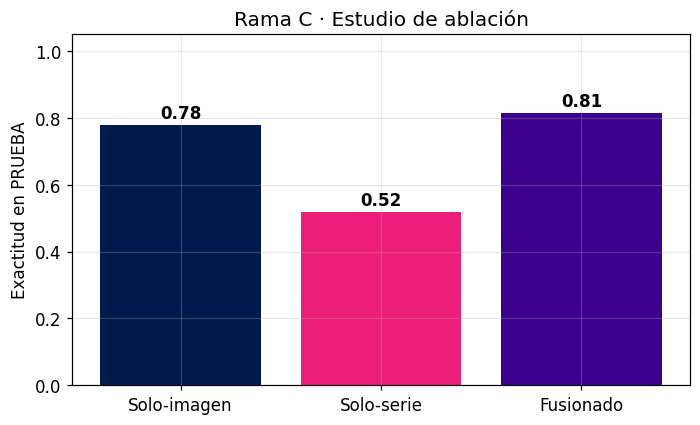


Lectura honesta del resultado (obligatoria en el informe):
- Solo-imagen (acc=0.78): la CNN de la Rama A ya aporta la señal principal.
- Solo-serie (acc=0.52 · azar=1/3≈0.33): el embedding de la serie NO tiene relación
  real con la etiqueta de imagen en este demo (generadores independientes).
- Fusionado (acc=0.81) es prácticamente IGUAL a solo-imagen (diferencia +0.04, dentro del margen de ruido esperable con solo 27 muestras de prueba): la serie no aportó información real, como es de esperar con una alineación artificial por índice.

En cualquiera de los tres casos, la conclusión metodológica es la misma: sin una clave de
co-registro genuina (Sección 3), NO se puede afirmar que la fusión aporta valor real, así la
métrica puntual suba o baje. Esa es la advertencia de leakage que exige la rúbrica.


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# TODO (estudiante) · Rama C: cabeza de fusión, entrenamiento conjunto y ablación
# Qué hace · Extrae embeddings REALES de la CNN (Rama A) y la RNN (Rama B) ya entrenadas,
#            los fusiona, entrena una cabeza densa de decisión y ejecuta el estudio de
#            ablación (solo-imagen / solo-serie / fusionado).
# Por qué  · Es el criterio de MAYOR peso de la rúbrica (30 %): exige demostrar que la
#            fusión aporta algo real, no solo concatenar vectores.

# --- 0) Declaración de alineación de este demo (léase antes de todo) ------------------
# Las imágenes sintéticas (Rama A) y las ventanas de la serie (Rama B) NO comparten una
# clave real de entidad-periodo: son dos generadores independientes. Para poder mostrar la
# MECÁNICA de la fusión, aquí se emparejan por ÍNDICE (fila i de embeddings de imagen con
# fila i de embeddings de serie) -- esto es EXACTAMENTE el caso de "fuga de datos por
# alineación artificial" que advierte la Sección 3: se declara explícitamente y NO se
# presenta como válido. En el proyecto real la clave de co-registro debe ser genuina
# (misma entidad, misma ventana espaciotemporal), por ejemplo un id de paciente + fecha.

# --- 1) Extraer embeddings reales (penúltima capa de cada rama) -----------------------
def extraer_embedding_cnn(modelo, x):
    """Propaga hasta la salida de avgpool (antes de la capa fc) -> vector de 512 dims (ResNet18)."""
    modelo.eval()
    with torch.no_grad():
        h = modelo.conv1(x);  h = modelo.bn1(h);  h = modelo.relu(h);  h = modelo.maxpool(h)
        h = modelo.layer1(h); h = modelo.layer2(h); h = modelo.layer3(h); h = modelo.layer4(h)
        h = modelo.avgpool(h)
        return torch.flatten(h, 1)

def extraer_embedding_rnn(modelo, x):
    """Toma el último estado oculto de la capa recurrente (antes de la cabeza de regresión)."""
    modelo.eval()
    with torch.no_grad():
        salidas, _ = modelo.rec(x)
        return salidas[:, -1]

# Todas las imágenes sintéticas, preprocesadas igual que en el entrenamiento de la Rama A
_ximg_full = torch.tensor(X_img)
_ximg_full = F.interpolate(_ximg_full, size=(IMG_SIZE_CNN, IMG_SIZE_CNN),
                            mode="bilinear", align_corners=False).repeat(1, 3, 1, 1).to(DEVICE)
z_img_real = extraer_embedding_cnn(modelo_A, _ximg_full)                 # (N_img, 512)

_xseq_full = torch.tensor(X_seq).to(DEVICE)
z_seq_real = extraer_embedding_rnn(modelo_B, _xseq_full)                  # (N_seq, hidden)

# Co-registro por ÍNDICE (declarado como NO real; ver nota de arriba)
N_FUSION = min(len(z_img_real), len(z_seq_real))
z_img_real = z_img_real[:N_FUSION]
z_seq_real = z_seq_real[:N_FUSION]
etiquetas_fusion = y_img[:N_FUSION]              # se reutiliza la etiqueta de imagen (3 clases)

z_fusion = torch.cat([z_img_real, z_seq_real], dim=1)
print(f"z_img {tuple(z_img_real.shape)}  +  z_seq {tuple(z_seq_real.shape)}  ->  "
      f"z_fusion {tuple(z_fusion.shape)}  ·  N co-registrado (por índice): {miles(N_FUSION)}")

# --- 2) Cabeza de fusión (red densa de decisión) ---------------------------------------
class CabezaFusion(nn.Module):
    def __init__(self, dim_in, n_salidas=len(CLASES_A), oculta=64):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(dim_in, oculta), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(oculta, n_salidas))

    def forward(self, z):             # z = [z_img || z_seq] co-registrado
        return self.red(z)

# --- 3) Entrenamiento conjunto (reutilizable para cualquier variante de ablación) -----
def entrenar_fusion(dim_in, z, etiquetas, epocas=60, lr=1e-3, semilla=SEMILLA):
    """Convierte z/etiquetas a tensores, parte train/val/test, entrena la cabeza con los
    5 pasos explícitos + early stopping, y devuelve (cabeza, historial, acc_test)."""
    torch.manual_seed(semilla)
    z_np = z.detach().cpu().numpy()
    (Xtr, ytr), (Xva, yva), (Xte, yte) = particion_estratificada(z_np, etiquetas, semilla)
    Xtr_t, ytr_t = torch.tensor(Xtr, dtype=torch.float32), torch.tensor(ytr, dtype=torch.long)
    Xva_t, yva_t = torch.tensor(Xva, dtype=torch.float32), torch.tensor(yva, dtype=torch.long)
    Xte_t, yte_t = torch.tensor(Xte, dtype=torch.float32), torch.tensor(yte, dtype=torch.long)

    cabeza = CabezaFusion(dim_in=dim_in).to(DEVICE)
    criterio = nn.CrossEntropyLoss()
    optimizador = torch.optim.Adam(cabeza.parameters(), lr=lr)
    historial = {"train_loss": [], "val_acc": []}
    mejor_acc, sin_mejora, mejor_estado = 0.0, 0, None

    for _ in range(epocas):
        cabeza.train()
        optimizador.zero_grad()                              # (3) zero_grad
        salida = cabeza(Xtr_t.to(DEVICE))                      # (1) forward
        loss = criterio(salida, ytr_t.to(DEVICE))               # (2) pérdida
        loss.backward()                                          # (4) backward
        optimizador.step()                                        # (5) step
        historial["train_loss"].append(loss.item())

        cabeza.eval()
        with torch.no_grad():
            acc = (cabeza(Xva_t.to(DEVICE)).argmax(1) == yva_t.to(DEVICE)).float().mean().item()
        historial["val_acc"].append(acc)
        if acc > mejor_acc:
            mejor_acc, sin_mejora = acc, 0
            mejor_estado = {k: v.clone() for k, v in cabeza.state_dict().items()}
        else:
            sin_mejora += 1
            if sin_mejora >= 10:
                break

    if mejor_estado is not None:
        cabeza.load_state_dict(mejor_estado)
    cabeza.eval()
    with torch.no_grad():
        acc_test = (cabeza(Xte_t.to(DEVICE)).argmax(1) == yte_t.to(DEVICE)).float().mean().item()
    return cabeza, historial, acc_test

# --- 4) Estudio de ablación: solo-imagen / solo-serie / fusionado ---------------------
print("\n--- Ablación: solo-imagen vs. solo-serie vs. fusionado ---")
cabeza_img, hist_img, acc_img = entrenar_fusion(z_img_real.shape[1], z_img_real, etiquetas_fusion)
print(f"Solo-imagen  (dim={z_img_real.shape[1]:>3}) · acc PRUEBA = {acc_img:.3f}")

cabeza_seq, hist_seq, acc_seq = entrenar_fusion(z_seq_real.shape[1], z_seq_real, etiquetas_fusion)
print(f"Solo-serie   (dim={z_seq_real.shape[1]:>3}) · acc PRUEBA = {acc_seq:.3f}")

cabeza_fusion, hist_fusion, acc_fusion = entrenar_fusion(z_fusion.shape[1], z_fusion, etiquetas_fusion)
print(f"Fusionado    (dim={z_fusion.shape[1]:>3}) · acc PRUEBA = {acc_fusion:.3f}")

fig, ax = plt.subplots(figsize=(6.5, 4))
nombres_abl = ["Solo-imagen", "Solo-serie", "Fusionado"]
valores_abl = [acc_img, acc_seq, acc_fusion]
ax.bar(nombres_abl, valores_abl, color=[USTA_NAVY, USTA_ROSA, USTA_MORADO])
for i, v in enumerate(valores_abl):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")
ax.set_ylim(0, 1.05); ax.set_ylabel("Exactitud en PRUEBA")
ax.set_title("Rama C · Estudio de ablación")
plt.tight_layout(); plt.show()

N_TEST_ABL = max(1, round(N_FUSION * 0.15))   # tamaño aproximado del test de ablación
umbral_ruido = 1.0 / np.sqrt(N_TEST_ABL)          # variación esperable solo por azar de muestreo

print("\nLectura honesta del resultado (obligatoria en el informe):")
print(f"- Solo-imagen (acc={acc_img:.2f}): la CNN de la Rama A ya aporta la señal principal.")
print(f"- Solo-serie (acc={acc_seq:.2f} · azar=1/3≈0.33): el embedding de la serie NO tiene relación")
print("  real con la etiqueta de imagen en este demo (generadores independientes).")
diferencia = acc_fusion - acc_img
if abs(diferencia) <= umbral_ruido:
    lectura = (f"Fusionado (acc={acc_fusion:.2f}) es prácticamente IGUAL a solo-imagen "
               f"(diferencia {diferencia:+.2f}, dentro del margen de ruido esperable con solo "
               f"{N_TEST_ABL} muestras de prueba): la serie no aportó información real, como es "
               "de esperar con una alineación artificial por índice.")
elif diferencia > 0:
    lectura = (f"Fusionado (acc={acc_fusion:.2f}) aparece por ENCIMA de solo-imagen "
               f"(diferencia {diferencia:+.2f}), pero con solo {N_TEST_ABL} muestras de prueba "
               "esa diferencia es compatible con ruido de muestreo, NO con una mejora real: "
               "el embedding de la serie no tiene ninguna relación causal con la etiqueta de imagen "
               "en este demo. Con datos reales y co-registro genuino, una mejora sostenida SÍ sería evidencia válida.")
else:
    lectura = (f"Fusionado (acc={acc_fusion:.2f}) queda por DEBAJO de solo-imagen "
               f"(diferencia {diferencia:+.2f}): agregar un embedding sin relación real con la "
               "etiqueta añadió ruido a la cabeza de decisión en vez de información útil.")
print(f"- {lectura}")
print("\nEn cualquiera de los tres casos, la conclusión metodológica es la misma: sin una clave de")
print("co-registro genuina (Sección 3), NO se puede afirmar que la fusión aporta valor real, así la")
print("métrica puntual suba o baje. Esa es la advertencia de leakage que exige la rúbrica.")

cabeza_fusion_final = cabeza_fusion  # variable que usará el checklist / informe final

## 4. Checklist de entrega + rúbrica

Una vez completadas las tres ramas sobre los **datos reales** del proyecto (no sobre estos datos sintéticos), la Fase 2 se entrega con estas piezas. La calificación se rige por la **rúbrica unificada** (abajo), cuyos cinco pesos suman 100 %.

**Checklist de entrega**

- [ ] **Notebook** (`.ipynb`) ejecutable y documentado con las tres ramas: CNN con *transfer learning* y Grad-CAM (A), LSTM + GRU + RNN de contraste (B), cabeza de fusión con estudio de ablación (C).
- [ ] **Pesos entrenados** (`.h5`/`.pth`) de los modelos, con *checkpoints* a Drive documentados.
- [ ] **Informe técnico único** (PDF, **máx. 8 páginas**) con narrativa para audiencia no técnica, recomendaciones accionables y citación APA.
- [ ] **Declaración de alineación** entre modalidades (clave de co-registro o, si es agregada, sus limitaciones).
- [ ] **Bitácora de IA**: qué se pidió, qué devolvió la IA y qué se **aceptó / modificó / rechazó** y por qué.
- [ ] **Auditoría a la IA**: al menos **un caso real** en que la IA falló (p. ej. dimensiones incompatibles, fuga de datos, métrica mal interpretada) y cómo se corrigió.
- [ ] Carpeta comprimida (`.zip`) con todo lo anterior.

**Rúbrica unificada de la Fase 2** (autoritativa; los pesos suman 100 %):

| Criterio (peso) | Qué evidencia |
|---|---|
| **1. Rama visual — CNN y Transfer Learning (20 %)** | Compara 2 arquitecturas preentrenadas (parámetros, profundidad, inferencia); justifica *Feature Extraction* vs *Fine-Tuning*; aporta **Grad-CAM** y evaluación por clase. |
| **2. Rama temporal — LSTM/GRU + RNN de contraste (20 %)** | LSTM y GRU correctos + RNN simple de contraste; respeta el **orden temporal**; evidencia el desvanecimiento del gradiente; compara con RMSE/MAE/MAPE. |
| **3. Fusión, ablación y alineación legítima (30 %)** | Demuestra la **clave de alineación** entre modalidades; fusión funcional con **ablación** (solo-imagen / solo-serie / fusionado) y análisis honesto, evitando *leakage*. |
| **4. Uso responsable de IA (15 %)** | **Bitácora** con decisiones deliberadas; **sustentación** oral de cada decisión; **auditoría** con un fallo no trivial corregido. |
| **5. Comunicación de resultados (15 %)** | Visualizaciones estáticas claras (dashboard interactivo como *bonus*); informe con narrativa, recomendaciones accionables y citación APA. |

**Total de la Fase 2: 30 % del curso · 46 h.**

> ⚠️ **Este andamiaje no se entrega tal cual**
> Este cuaderno es punto de partida y trabaja con **datos sintéticos**. La entrega evaluable debe aplicarse a los **datos reales** del problema elegido (visión + serie del mismo cliente de la Fase 1), e incluir los pesos, el informe, la bitácora y la auditoría de IA. Reutilizar este scaffold sin adaptarlo **no satisface** la actividad.

### 🔗 Relacionado
- Página principal de la bóveda y mapa del Segundo Cerebro.
- Syllabus del Curso y Ruta de Aprendizaje.
- Documento maestro: **Proyecto Integrador Centinela** (especificación longitudinal de las tres fases).
- **Fase 2 (evaluable):** Actividad 2 · "Sistema Multimodal Especializado" (ramas A, B y C).
- **Base teórica:** Módulo 2 — Capítulos 2.1 (CNN), 2.2 (LSTM/GRU) y 2.3 (modelos generativos).
- **Fases vecinas:** Fase 1 (línea base con MLP) · Fase 3 (pipeline y despliegue en borde).
- **Uso de IA:** plantilla de la Bitácora de IA para registrar el proceso de la fase.
